# 실습 2-2 : 로지스틱 회귀

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 구조적 정보 / 통계적 정보
- 범주형 변수 처리 (One-Hot Encoding)
- 입출력 변수 분할
- 학습/테스트 데이터 분할
- 스케일링

2. 로지스틱 회귀
- 모델 학습 및 성능 평가
- 회귀 계수 해석

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

### 데이터 불러오기

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-2_data.csv"))

---

## 1) 데이터 탐색 및 전처리

### 1-1) 구조적 정보

In [23]:
# 앞부분 데이터 확인
MF_Data.head(n=10)

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No
5,67,84,Operator1,398,1,2,1901,1801,1153,1085,1547,2005,477,1217,1632,1324,1854,1739,95,No
6,67,83,Operator1,847,0,2,1849,1141,1609,982,1159,672,1128,663,1114,1838,290,1192,96,No
7,67,76,Operator1,1021,2,1,185,170,952,1183,1329,427,1638,850,379,1529,755,844,97,No
8,65,80,Operator3,1731,2,0,1424,1176,1223,621,647,369,239,1196,1944,1583,1630,237,98,No
9,63,80,Operator3,415,0,0,1008,1086,1759,1946,1814,1754,1442,341,1097,1819,472,491,99,No


In [32]:
# Failure와 "Hours Since Previous Failure"의 관계가 궁금...

MF_Data["Failure"].value_counts(dropna=False)

mask = MF_Data["Failure"].astype(str).str.strip().str.lower().eq("yes")
yes_pos = MF_Data.index[mask]
len(yes_pos)

if len(yes_pos) == 0:
    print("Failure == 'yes' rows not found. Check value_counts().")
else:
    pos = MF_Data.index.get_loc(yes_pos[0])
    display(MF_Data.iloc[max(pos-5, 0) : min(pos+11, len(MF_Data))][["Hours Since Previous Failure", "Failure"]])

,Hours Since Previous Failure,Failure
143,233,No
144,234,No
145,235,No
146,236,No
147,237,No
148,238,Yes
149,1,No
150,2,No
151,3,No
152,4,No


In [4]:
# 데이터 정보 확인
MF_Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Temperature                   7900 non-null   int64
 1   Humidity                      7900 non-null   int64
 2   Operator                      7900 non-null   str  
 3   Measure1                      7900 non-null   int64
 4   Measure2                      7900 non-null   int64
 5   Measure3                      7900 non-null   int64
 6   Measure4                      7900 non-null   int64
 7   Measure5                      7900 non-null   int64
 8   Measure6                      7900 non-null   int64
 9   Measure7                      7900 non-null   int64
 10  Measure8                      7900 non-null   int64
 11  Measure9                      7900 non-null   int64
 12  Measure10                     7900 non-null   int64
 13  Measure11                     7900 non-null 

In [5]:
# 데이터 크기 확인
print("데이터 크기 :", MF_Data.shape)

데이터 크기 : (7900, 20)


- 현재 설비 상태(온도, 습도, 센서값, 이전 고장 후 경과시간)를 이용하여 향후 고장(Failure) 발생 여부를 예측하는 이진 분류 데이터셋

### 1-2) 통계적 정보

In [ ]:
# 요약 통계량 확인
MF_Data.describe(include="all")  #object 변수도 표현

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
count,7900.000000,7900.000000,7900,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900
unique,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Operator2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,1751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7825
mean,64.055949,83.703671,NaN,1093.450380,1.488608,1.002025,1068.763924,1075.140000,1077.938228,1089.496076,1075.945190,1082.146962,1081.997975,1088.974684,1088.998228,1074.699241,1091.435949,1083.851899,210.289241,NaN
std,2.668864,4.806356,NaN,535.438555,1.114985,0.813854,535.724483,533.727253,533.450621,537.130674,537.184388,531.296016,538.075952,534.544434,532.217592,535.322092,536.685002,537.114706,143.875473,NaN
min,60.000000,65.000000,NaN,155.000000,0.000000,0.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,1.000000,NaN
25%,62.000000,80.000000,NaN,633.000000,0.000000,0.000000,605.000000,603.750000,626.000000,625.000000,609.000000,634.000000,618.000000,628.000000,630.000000,605.000000,622.000000,615.750000,89.000000,NaN
50%,64.000000,84.000000,NaN,1098.500000,2.000000,1.000000,1056.000000,1075.000000,1073.000000,1091.000000,1073.000000,1076.000000,1076.500000,1093.000000,1081.000000,1064.500000,1090.500000,1078.000000,192.000000,NaN
75%,66.000000,87.000000,NaN,1556.000000,2.000000,2.000000,1530.000000,1541.250000,1541.250000,1561.000000,1540.000000,1527.250000,1547.000000,1548.000000,1549.500000,1537.000000,1564.250000,1552.000000,314.000000,NaN


### 1-3) 시각적 탐색

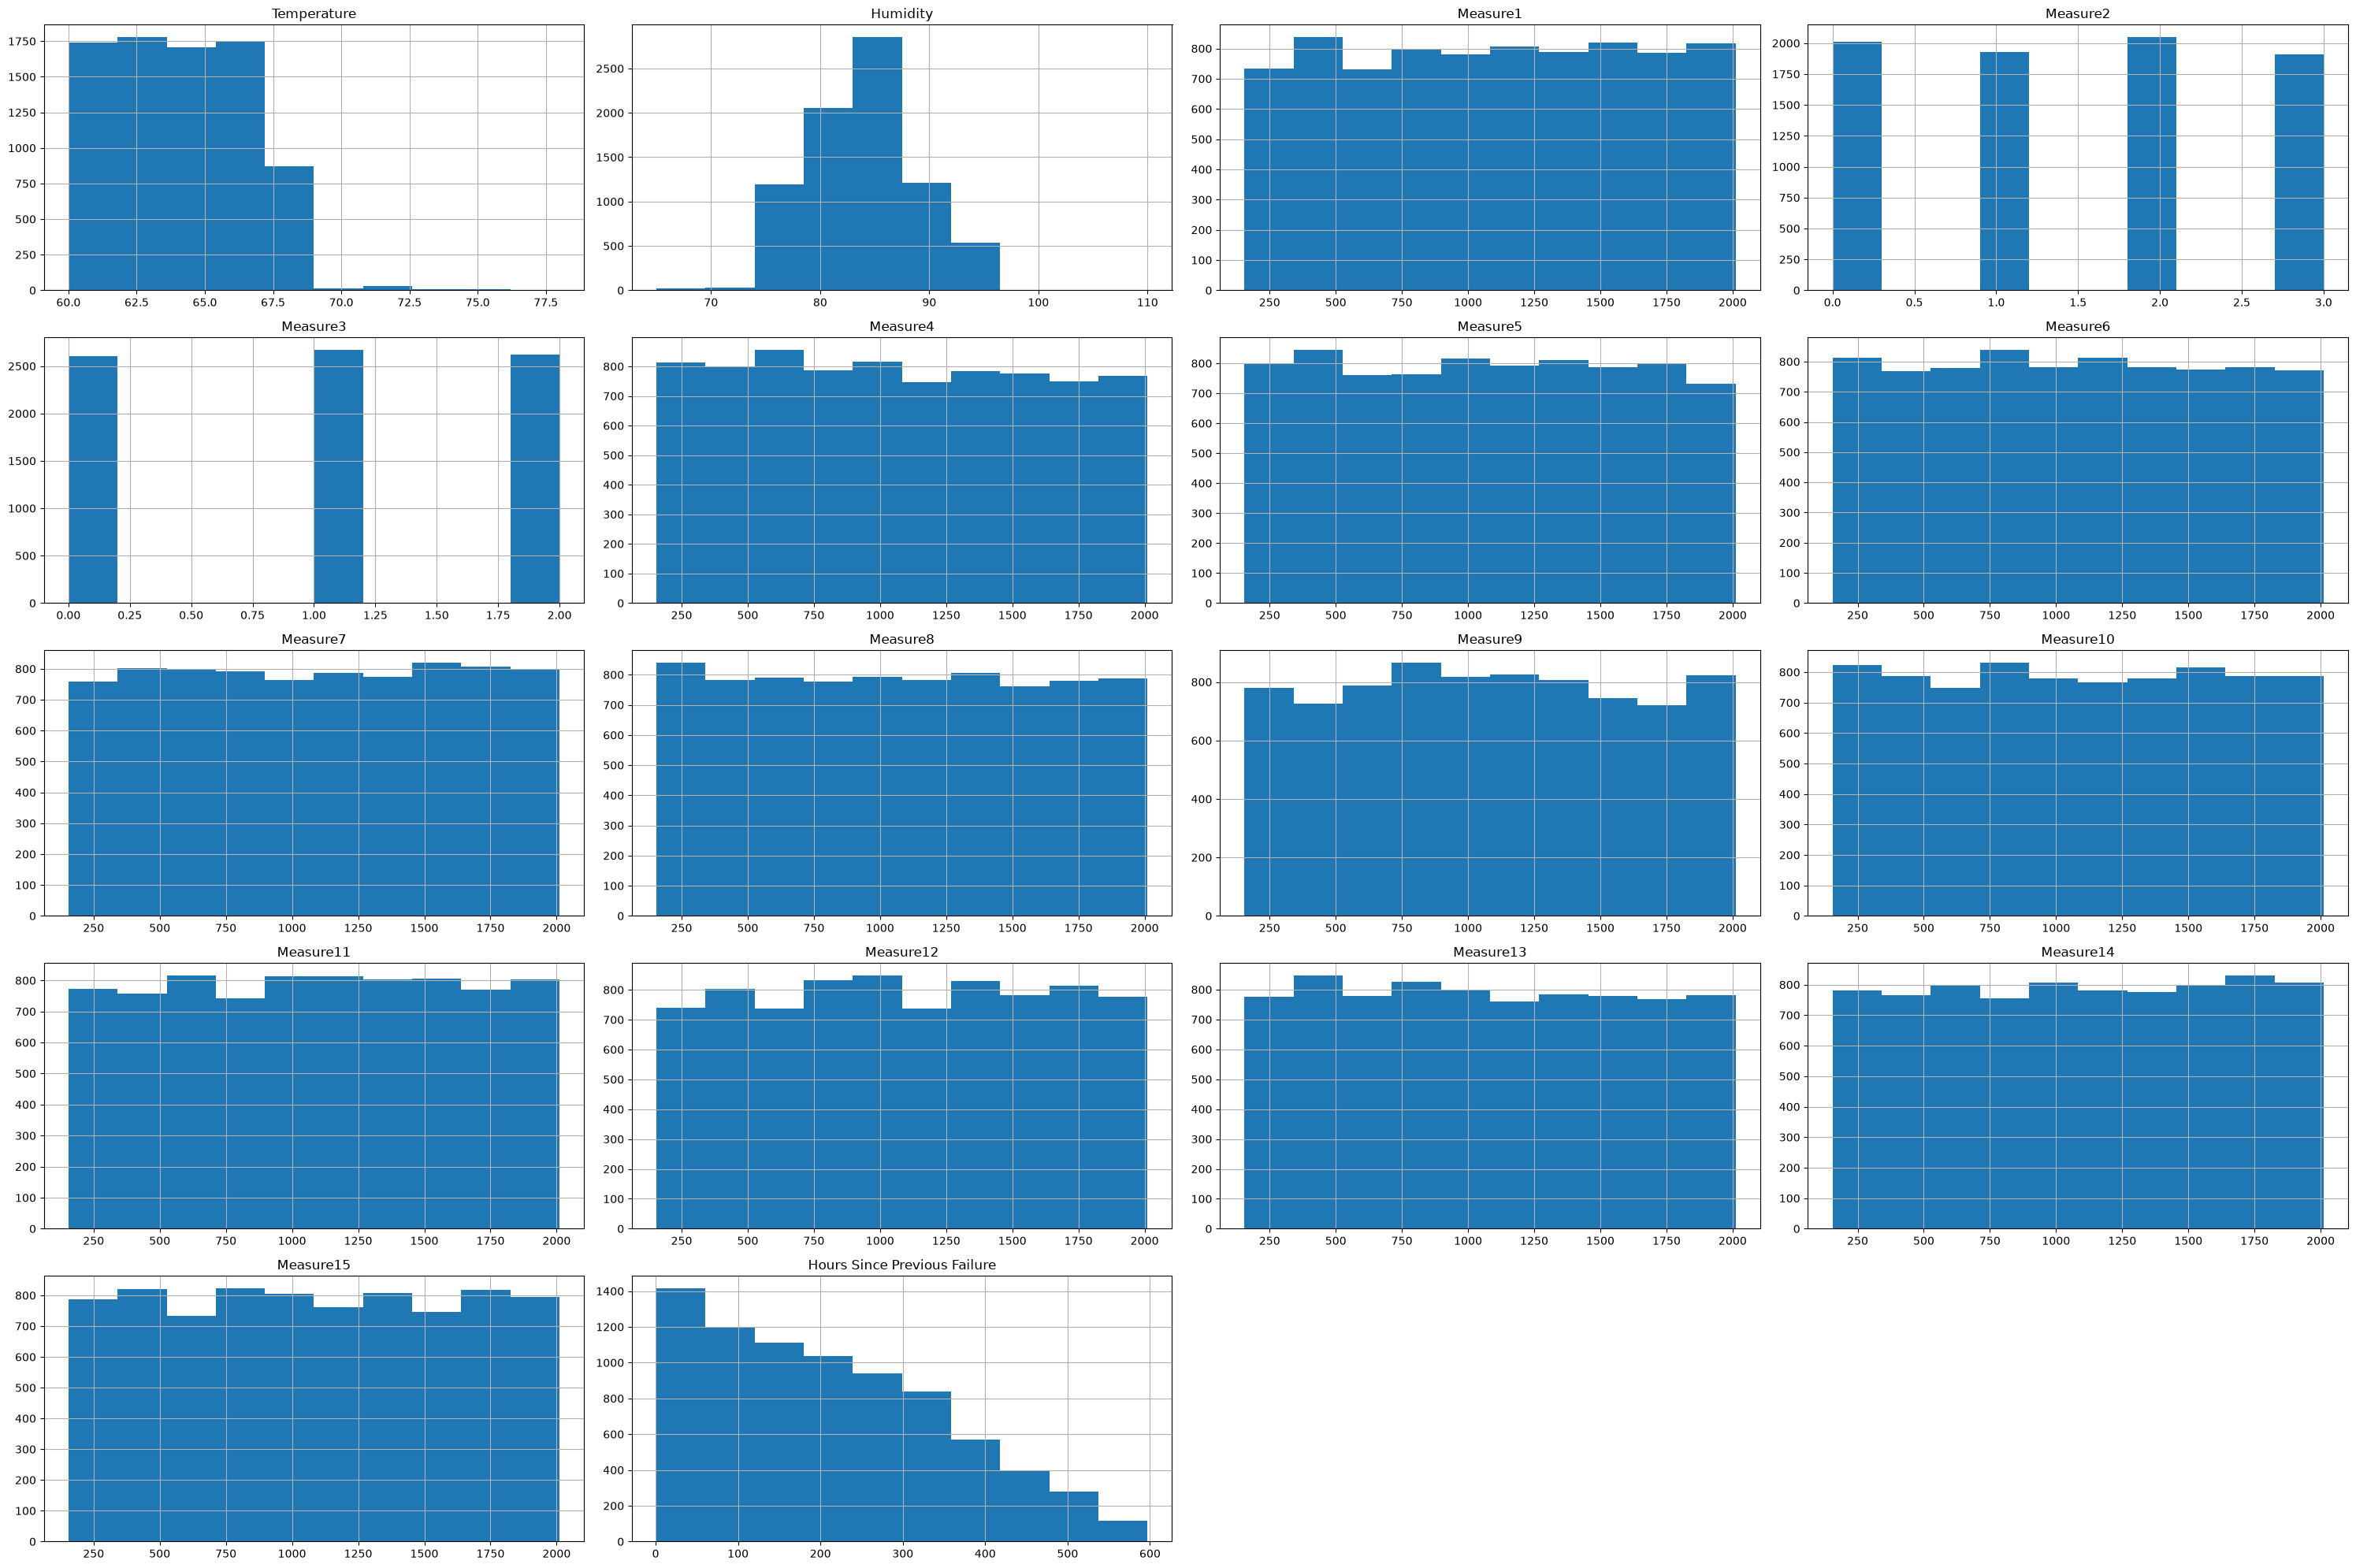

In [35]:
# 히스토그램
MF_Data.hist(figsize=(30, 20))
plt.tight_layout()
#plt.gcf().set_constrained_layout(True)
plt.show()

# 숫자 변수도 unique값이 적은(몇가지 없는)건 범주형 변수 취급할 수 있다.

> Measure2와 Measure3은 값이 소수의 정수값만 가지므로 **범주형 변수**로 처리해야 함

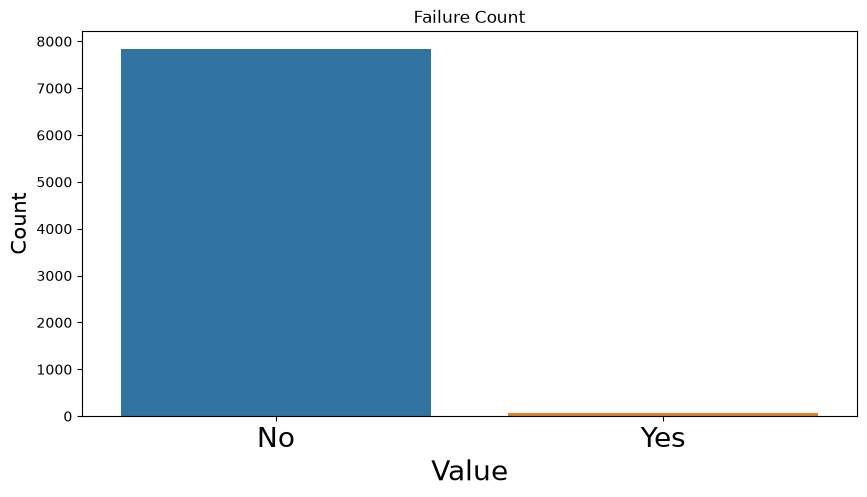

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Failure Count")

counts = MF_Data["Failure"].value_counts()

sns.barplot(x=counts.index,
            y=counts.values,
            hue=counts.index)

plt.xticks(fontsize=20)
plt.xlabel("Value",fontsize=20)
plt.ylabel("Count",fontsize=15)
plt.show()

# Data 불균형 확인할 수 있음

### 1-4) 입출력 변수 분할

In [9]:
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

### 1-5) 범주형 변수 처리 (One-Hot Encoding)

> **One-Hot Encoding**은 범주형 변수의 각 항목을 0과 1로 표현하는 방법임
> - 범주가 k개인 변수를 k개의 새로운 이진 변수로 변환함
> - `pd.get_dummies()`를 사용하면 범주형 변수를 자동으로 One-Hot Encoding 할 수 있음

In [10]:
# Measure2, Measure3을 범주형으로 변환
print("Measure2 고유값:", X["Measure2"].unique())
print("Measure3 고유값:", X["Measure3"].unique())

X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")

Measure2 고유값: [1 0 2 3]
Measure3 고유값: [1 2 0]


In [11]:
# One-Hot Encoding 적용
X = pd.get_dummies(X)
data_columns = X.columns

X.head()

,Temperature,Humidity,Measure1,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,...,Operator_Operator6,Operator_Operator7,Operator_Operator8,Measure2_0,Measure2_1,Measure2_2,Measure2_3,Measure3_0,Measure3_1,Measure3_2
0,67,82,291,1041,846,334,706,1086,256,1295,...,False,False,False,False,True,False,False,False,True,False
1,68,77,1180,1915,1194,637,1093,524,919,245,...,False,False,False,False,True,False,False,False,True,False
2,64,76,1406,511,1577,1121,1948,1882,1301,273,...,False,False,False,False,True,False,False,False,True,False
3,63,80,550,1754,1834,1413,1151,945,1312,1494,...,False,False,False,False,True,False,False,False,True,False
4,65,81,1928,1326,1082,233,1441,1736,1033,1549,...,False,False,False,False,True,False,False,False,False,True


### 1-6) 출력변수 확인

> 불량(Yes) 비율이 약 0.9%로 **매우 불균형한 데이터**임

In [12]:
# 클래스 비율 확인
print(Y.value_counts())
print()
print(Y.value_counts(normalize=True))

Failure
No     7825
Yes      75
Name: count, dtype: int64

Failure
No     0.990506
Yes    0.009494
Name: proportion, dtype: float64


In [13]:
# 출력변수 값 변경 (No -> 0, Yes -> 1) / 중요하게 생각하는 범주를 1로 맵핑한다.
Y = Y.replace({"No": 0, "Yes": 1}).infer_objects(copy=False)
Y.value_counts()

C:\Users\Admin\AppData\Local\Temp\ipykernel_28312\3588185558.py:2: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  Y = Y.replace({"No": 0, "Yes": 1}).infer_objects(copy=False)


Failure
0    7825
1      75
Name: count, dtype: int64

### 1-7) 학습/테스트 데이터 분할

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)
# stratify=Y를 해야 불균형한 Y data를 공정하게 가져다 train set을 만들 수 있다.

print("전체 데이터 크기   :", X.shape)
print("학습 데이터 크기   :", X_train.shape)
print("테스트 데이터 크기 :", X_test.shape)

전체 데이터 크기   : (7900, 31)
학습 데이터 크기   : (5530, 31)
테스트 데이터 크기 : (2370, 31)


In [15]:
# 클래스 비율이 유지되는지 확인
print("Y 클래스 비율")
print(np.round(Y.value_counts(normalize=True), 3))
print()
print("Y_train 클래스 비율")
print(np.round(Y_train.value_counts(normalize=True), 3))
print()
print("Y_test 클래스 비율")
print(np.round(Y_test.value_counts(normalize=True), 3))

Y 클래스 비율
Failure
0    0.991
1    0.009
Name: proportion, dtype: float64

Y_train 클래스 비율
Failure
0    0.99
1    0.01
Name: proportion, dtype: float64

Y_test 클래스 비율
Failure
0    0.991
1    0.009
Name: proportion, dtype: float64


### 1-8) 스케일링

> 로지스틱 회귀는 입력변수의 **스케일에 민감**하므로, MinMax 또는 Standard 스케일링을 적용해야함

In [16]:
mc = MinMaxScaler()
X_train = mc.fit_transform(X_train)
X_test = mc.transform(X_test)

---

## 2) 로지스틱 회귀

> **로지스틱 회귀**는 출력변수가 범주형(정상/불량)인 경우에 사용되는 분류 모델임
> - 특정 사건이 발생할 **확률**을 예측하며, 확률이 기준값(보통 0.5) 이상이면 해당 클래스로 분류함
> - 로지스틱 함수: $p(X) = \frac{e^{\hat{\beta}_0 + \hat{\beta}_1 X_1 + \cdots + \hat{\beta}_k X_k}}{1 + e^{\hat{\beta}_0 + \hat{\beta}_1 X_1 + \cdots + \hat{\beta}_k X_k}}$
> - 회귀 계수 $\hat{\beta}_k$가 양수면 $X_k$가 증가할수록 불량 확률이 높아지고, 음수면 낮아짐

In [17]:
# 분류 모형 성능 지표 산출 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % (accuracy_score(real, pred)))
    print("Precision : %.3f" % (precision_score(real, pred)))
    print("Recall    : %.3f" % (recall_score(real, pred)))
    print("F1-score  : %.3f" % (f1_score(real, pred)))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 2-1) 모델 학습

In [18]:
LR_model = LogisticRegression()
LR_model.fit(np.array(X_train), np.array(Y_train))

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### 2-2) 회귀 계수 확인

> 로지스틱 회귀에서 회귀 계수의 절대값이 클수록 해당 변수의 **분류 영향력이 큼**.

In [19]:
coef_data = pd.DataFrame({"Variable": data_columns, "Coef": np.abs(LR_model.coef_[0])})
coef_data.sort_values(by="Coef", ascending=False)

,Variable,Coef
0,Temperature,6.475519
1,Humidity,5.671526
15,Hours Since Previous Failure,1.891511
23,Operator_Operator8,0.814493
10,Measure11,0.699583
9,Measure10,0.626409
7,Measure8,0.538488
2,Measure1,0.537912
8,Measure9,0.390579
25,Measure2_1,0.349988


### 2-3) 성능 평가

> 분류 모델의 주요 성능 지표:
> - **Accuracy (정확도)**: 전체 중 올바르게 분류한 비율
> - **Precision (정밀도)**: 불량으로 예측한 것 중 실제 불량의 비율
> - **Recall (재현율)**: 실제 불량 중 불량으로 예측한 비율
> - **F1-score**: Precision과 Recall의 조화 평균

In [ ]:
LR_predict = LR_model.predict(X_test)
get_classscore(Y_test, LR_predict)

# 불균형한 데이터라 F1-score가 낮다.

Accuracy  : 0.992
Precision : 1.000
Recall    : 0.136
F1-score  : 0.240

혼동행렬
[[2348    0]
 [  19    3]]


F1-score = “고장이라고 한 예측의 정확함(Precision)”과 “실제 고장을 얼마나 잘 잡았는지(Recall)”를 동시에 본 균형 점수

### 2-4) 확률 예측

> `predict_proba()`를 사용하면 각 클래스에 속할 **확률값**을 확인할 수 있음

In [22]:
# 테스트 데이터에 대한 사건 발생 확률 예측
LR_predict_proba = LR_model.predict_proba(X_test)
LR_predict_proba[:5]

array([[0.98980409, 0.01019591],
       [0.98435763, 0.01564237],
       [0.99840493, 0.00159507],
       [0.99861951, 0.00138049],
       [0.99230269, 0.00769731]])

---

## 3) Vibe Coding 실습

### 3-1) 전처리 심화

**[과제 1]** 지수는 불량(Failure) 비율이 약 0.9%에 불과하다는 점을 확인했습니다. 이처럼 클래스 불균형이 심한 데이터에서는 전처리, 로지스틱 회귀 모델 학습, 평가 방법, 고도화 등을 어떻게 설정해야 하는지가 중요합니다. AI와 함께 이를 해결할 수 있는 방법을 찾아보고, 실제로 적용하여 모델 성능이 얼마나 개선되는지 확인해 보세요.

### 3-2) 모델링 및 고도화 심화

**[과제 2]** 지수는 predict_proba로 얻은 불량 확률을 그냥 0.5 기준으로 나누는 게 이 데이터에 적합한지 의문이 듭니다. 임계값(threshold)을 바꿔가며 Precision과 Recall이 어떻게 trade-off 되는지 살펴보는 방법을 AI와 논의하고, 이 데이터에 더 적합한 임계값을 찾아 적용해 보세요.

**[과제 3]** 지수는 선형 회귀에서 Ridge·Lasso를 활용해 모델의 복잡도를 조절할 수 있다는 것을 배웠습니다. 이에 따라 로지스틱 회귀도 과적합을 방지하거나 모델의 복잡도를 조절할 수 있는 방법이 있는지 궁금해졌습니다. AI와 함께 모델 복잡도를 조절하는 기법을 찾아보고, 다양한 설정을 적용하여 성능과 회귀 계수의 변화를 비교해 보세요.

**[과제 4]** 지수는 모델이 구체적으로 어떤 케이스에서 틀리는지 직접 눈으로 확인하고 싶습니다. 모델이 잘못 예측한 데이터를 추려내는 방법을 AI와 상의해서 추출하고, 이 데이터들이 다른 데이터와 어떤 특징 차이를 보이는지 살펴보세요.